# Dark Matter Indirect Detection with Gammapy: Basics

Weakly Interacting Massive Particles (WIMPs) are among the most compelling 
candidates for Dark Matter (DM). If they exist, WIMPs can annihilate or decay 
into Standard Model particles — including gamma rays — that can be detected 
by gamma-ray instruments such as space-based telescopes (e.g. Fermi-LAT) or 
ground-based Imaging Atmospheric Cherenkov Telescopes (IACTs) like MAGIC, 
HESS, VERITAS, or the upcoming CTA Observatory.

The expected gamma-ray flux from a DM source has two independent components:

- **Astrophysical factor (J/D-factor):** encodes the spatial distribution of 
  DM along the line of sight. It depends on the assumed density profile and the 
  source distance.

- **Particle physics factor (dN/dE):** encodes the gamma-ray energy spectrum 
  produced per annihilation or decay event. It depends on the DM mass and the 
  dominant interaction channel.

The total flux is simply their product:

$$\Phi(E) = \frac{\langle\sigma v\rangle}{8\pi m_{\chi}^2} \cdot J \cdot \frac{dN}{dE}(E)$$

In this tutorial, we cover the building blocks needed to model this signal 
in Gammapy, using the **Draco dwarf spheroidal galaxy** as our target — one 
of the most DM-dominated objects in the local universe and a standard 
benchmark for indirect detection searches.

## Setup

In this part we upload all the neccesary packages for this tutorials and set up all the data regarding our target source.

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import astropy.units as u

from gammapy.maps import WcsGeom, WcsNDMap
from gammapy.astro.darkmatter import (
    JFactory,
    PrimaryFlux,
    profiles,
    DarkMatterAnnihilationSpectralModel,
    DarkMatterDecaySpectralModel

)
import astropy.units as u
from astropy.coordinates import SkyCoord
from regions import CircleSkyRegion

# Source position
position_dwarf_draco = SkyCoord(260.05, 57.915, frame="icrs", unit="deg")

# Distance
distance_dwarf_draco = 76 * u.kpc

## Spatial Distribution

To calculate the expected gamma-ray flux from Dark Matter, we first need to understand its spatial distribution. 

For **Dark Matter annihilation**, we use the **J-Factor**. It represents the astrophysical component of the flux and is the integral of the Dark Matter density squared ($\rho^2$) along the line of sight ($l$) integrated over a solid angle ($\Delta \Omega$), since it requires two particles to collide:

$$J = \int_{\Delta \Omega} \int_{l.o.s.} \rho^2(l, \Omega) \, dl \, d\Omega$$

For **Dark Matter decay**, we use the **D-Factor**. This depends linearly on the density ($\rho$), as it involves single particles decaying spontaneously:

$$D = \int_{\Delta \Omega} \int_{l.o.s.} \rho(l, \Omega) \, dl \, d\Omega$$

The calculation procedure in Gammapy is nearly identical for both cases; you only need to toggle a single parameter (`annihilation = True` or `False`) to switch between them.

In this section, we define the spatial parameters for the Draco dwarf spheroidal galaxy. First, we will describe the differnt density profiles availables and then how to calculate the astrophysical factors.

### Density profiles

The spatial distribution of Dark Matter within a halo is described by a 
density profile ρ(r). Different theoretical models and observational fits 
predict different shapes, particularly in the inner regions of the halo 
(the so-called "cusp vs core" debate).
The choice of profile is one of the dominant systematic uncertainties 
in DM indirect detection searches.

The current implemented profiles in Gammapy are: Burkert, Einasto, Isothermal, Moore, NFW and Zhao. 	

Each profile is characterized by two scale parameters fitted to observations:

- **r_s (scale radius):** the characteristic distance at which the profile 
  changes slope.

- **ρ_s (scale density):** the overall normalization of the profile, setting 
  the total amount of DM in the halo.

For Draco, we adopt the values from **----PONER REFERENCIA----**, obtained by fitting 
stellar kinematics data.

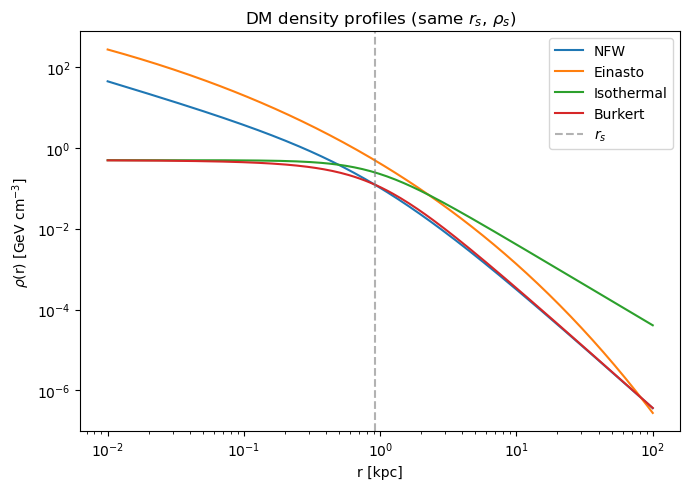

In [35]:
# Common parameters for comparison
r_s = 0.91 * u.kpc
rho_s = 1.3e7 * (u.M_sun / u.kpc**3)
rho_s_GeV = rho_s.to(u.GeV / u.cm**3, equivalencies=u.mass_energy())

# Define radial range
r = np.logspace(-2, 2, 200) * u.kpc

# Instantiate profiles
profile_list = {
    "NFW"       : profiles.NFWProfile(r_s=r_s, rho_s=rho_s_GeV),
    "Einasto"   : profiles.EinastoProfile(r_s=r_s, rho_s=rho_s_GeV),
    "Isothermal": profiles.IsothermalProfile(r_s=r_s, rho_s=rho_s_GeV),
    "Burkert"   : profiles.BurkertProfile(r_s=r_s, rho_s=rho_s_GeV),
}

# Plot
fig, ax = plt.subplots(figsize=(7, 5))

for name, profile in profile_list.items():
    rho = profile(r)
    ax.plot(r.value, rho.to("GeV cm-3").value, label=name)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("r [kpc]")
ax.set_ylabel(r"$\rho$(r) [GeV cm$^{-3}$]")
ax.set_title("DM density profiles (same $r_s$, $\\rho_s$)")
ax.axvline(r_s.value, color="gray", linestyle="--", alpha=0.6, label="$r_s$")
ax.legend()
plt.tight_layout()
plt.show()

### Astrophysical Factor

Now we are going to calculate the target source J-Factor an D-Factor. For this example we will use a NFW profile. The steps to follow are:

1. Set a geometry map of the source, where its sky position and region of interest is detailed (i.e. width, coordinates format...).
2. Compute the JFactor/DFactor using the JFactory class. It is possible to plot the results and also to integrate the factor in a desired region of interest. Not all telescopes have the same angular resolution, and Dark Matter halos are extended objects. To optimize our observation, we need to know how much Dark Matter signal is contained within a specific angular radius from the center of the galaxy.

It should be highlighted that the astrophysical factor can be computed with another tools and used within Gammapy, this is just an example if it wants to be calculated with this framework.

In [22]:
# Density profile
rho_s_msun_kpc3 = 1.3e7 * (u.M_sun / u.kpc**3)  

# Units conversion
rho_s_GeV_cm3 = rho_s_msun_kpc3.to(u.GeV / u.cm**3, equivalencies=u.mass_energy())

# Define the DM profile. Check profiles.DMProfile.__subclasses__() for more profiles
draco_profile = profiles.EinastoProfile(
    r_s=0.91 * u.kpc,       
    rho_s=rho_s_GeV_cm3
)

# Geometry map
geom_draco = WcsGeom.create(
    binsz=0.1,
    skydir=position_dwarf_draco,
    width=3.0,          
    frame="icrs"
)

#### J-Factor

/Users/alexcervino/anaconda3/envs/darkmatter_env/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2605: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)
/Users/alexcervino/anaconda3/envs/darkmatter_env/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2605: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)
/Users/alexcervino/anaconda3/envs/darkmatter_env/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2605: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)


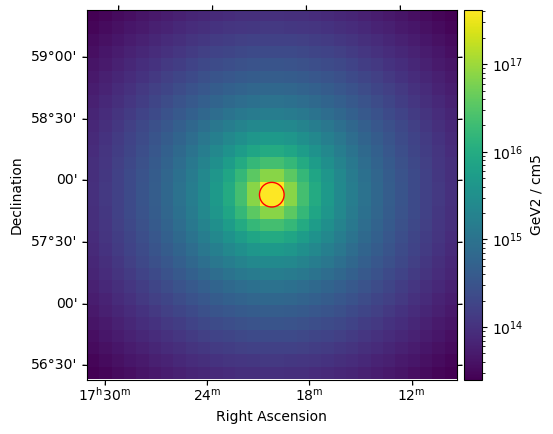

J-factor integrated on 0.1 deg circle: 1.66e+18 GeV2 / cm5


In [23]:
# JFactory creation for ANNIHILATION
jfactory = JFactory(
    geom=geom_draco,
    profile=draco_profile,
    distance=distance_dwarf_draco,
    annihilation = True
)

# Compute J factor
jfact_draco = jfactory.compute_jfactor()

# Map construction for plotting
jfact_map_draco = WcsNDMap(geom=geom_draco, data=jfact_draco.value, unit=jfact_draco.unit)

plt.figure()

ax = jfact_map_draco.plot(cmap="viridis", norm=LogNorm(), add_cbar=True)

# Define a region of interest (i.e., 0.1 deg circle)
sky_reg = CircleSkyRegion(center=position_dwarf_draco, radius=0.1 * u.deg)
pix_reg = sky_reg.to_pixel(wcs=geom_draco.wcs)
pix_reg.plot(ax=ax, facecolor="none", edgecolor="red", label="0.1 deg circle")
plt.show()

# Integration of JFactor within that region
total_jfact = pix_reg.to_mask().multiply(jfact_draco).sum()
print(f"J-factor integrated on 0.1 deg circle: {total_jfact:.3g}")

#### D-Factor

/Users/alexcervino/anaconda3/envs/darkmatter_env/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2605: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)
/Users/alexcervino/anaconda3/envs/darkmatter_env/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2605: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)
/Users/alexcervino/anaconda3/envs/darkmatter_env/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2605: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)


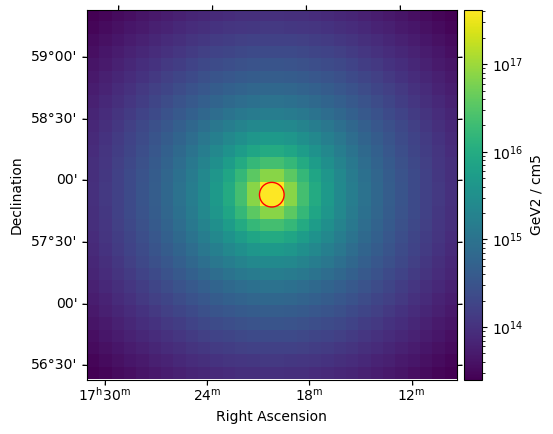

D-factor integrated on 0.1 deg circle: 2.27e+17 GeV / cm2


In [24]:
# JFactory creation for ANNIHILATION
dfactory = JFactory(
    geom=geom_draco,
    profile=draco_profile,
    distance=distance_dwarf_draco,
    annihilation = False #Set for decay
)

# Compute J factor
dfact_draco = dfactory.compute_jfactor()

# Map construction for plotting
dfact_map_draco = WcsNDMap(geom=geom_draco, data=jfact_draco.value, unit=jfact_draco.unit)

plt.figure()

ax = dfact_map_draco.plot(cmap="viridis", norm=LogNorm(), add_cbar=True)

# Define a region of interest (i.e., 0.1 deg circle)
sky_reg = CircleSkyRegion(center=position_dwarf_draco, radius=0.1 * u.deg)
pix_reg = sky_reg.to_pixel(wcs=geom_draco.wcs)
pix_reg.plot(ax=ax, facecolor="none", edgecolor="red", label="0.1 deg circle")
plt.show()

# Integration of JFactor within that region
total_dfact = pix_reg.to_mask().multiply(dfact_draco).sum()
print(f"D-factor integrated on 0.1 deg circle: {total_dfact:.3g}")

## Spectral morphology

The second component of our model is governed by particle physics. When Weakly 
Interacting Massive Particles (WIMPs) annihilate (or decay), they produce Standard 
Model particles that eventually decay or hadronize into gamma rays.

The energy spectrum of these gamma rays, dN/dE, depends on two quantities:

- **The DM mass (m_χ):** sets the maximum energy of the photons, since 
  E_max = m_χ for annihilation (or m_χ/2 for decay).
- **The annihilation channel:** determines the shape of the spectrum. 
  Different final states (quarks, leptons, gauge bosons) produce different 
  gamma-ray spectra through different decay and hadronization chains.

Gammapy implements these spectra via look-up tables from two sources:

- **PPPC4DMID** (Cirelli et al. 2011): tables computed with PYTHIA for a wide 
  range of masses and channels, including electroweak corrections. The standard 
  reference for most indirect detection analyses.
- **CosmiXs** (Boudaud et al. 2023): more recent tables with updated Monte Carlo 
  generators, particularly relevant at high masses (above ~100 TeV) where 
  PPPC4DMID may be less accurate.

Currently, the default source is PPPC4DMID.

The `PrimaryFlux` class in Gammapy interpolates these tables and returns 
dN/dE as a spectral model that can be directly combined with the J-factor 
to compute the expected flux (as shown in the next section).

Here we plot the primary gamma-ray spectrum for a **10 TeV** DM particle 
annihilating into several typical channels. For the decay, the procedure is the same, but **the mass must be divided by 2**.

> **Note:** Computing these spectra requires the Gammapy datasets to be 
> downloaded and the `GAMMAPY_DATA` environment variable to be set. 
> Please follow the instructions at 
> https://docs.gammapy.org/dev/getting-started/index.html#recommended-setup 
> before running the cells below.

### Example with PPPC4DM

The filename is not defined. Therefore, the model will not be serialised correctly. To set the filename, the "template_model.filename" attribute can be used.
The filename is not defined. Therefore, the model will not be serialised correctly. To set the filename, the "template_model.filename" attribute can be used.
The filename is not defined. Therefore, the model will not be serialised correctly. To set the filename, the "template_model.filename" attribute can be used.
The filename is not defined. Therefore, the model will not be serialised correctly. To set the filename, the "template_model.filename" attribute can be used.
The filename is not defined. Therefore, the model will not be serialised correctly. To set the filename, the "template_model.filename" attribute can be used.


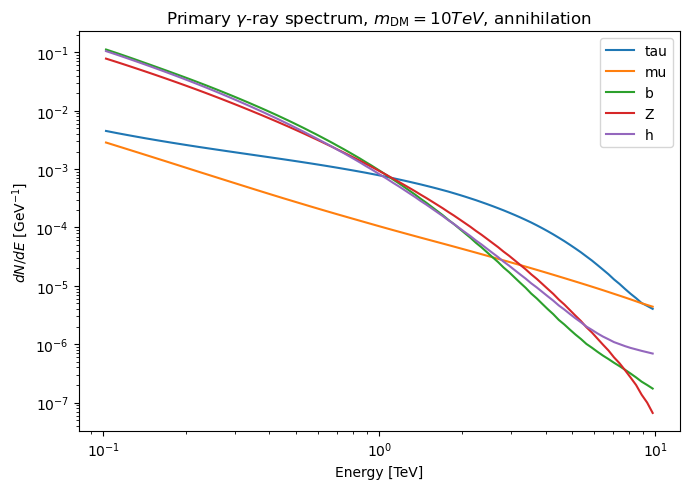

In [32]:
# Define the DM mass and channels of interest
mDM = 10.0 * u.TeV
channels = ["tau", "mu", "b", "Z", "h"]

# To see all available channels: print(PrimaryFlux(mDM=mDM, channel="b").allowed_channels)
fig, ax = plt.subplots(figsize=(7, 5))

for channel in channels:
    fluxes = PrimaryFlux(mDM=mDM, channel=channel)
    fluxes.plot(
        energy_bounds=[mDM / 100, mDM],
        ax=ax,
        label=channel,
        yunits=u.Unit("1/GeV"),
    )

ax.set_yscale("log")
ax.set_xlabel("Energy [TeV]")
ax.set_ylabel(r"$dN/dE$ [GeV$^{-1}$]")
ax.set_title(
    rf"Primary $\gamma$-ray spectrum, $m_{{\rm DM}} = {mDM:.0f}$, annihilation"
)
ax.legend()
plt.tight_layout()
plt.show()

### Example with CosmiXs

To change to CosmiXs source, it must be set into the Primary Flux class with an homonymous parameter.

The filename is not defined. Therefore, the model will not be serialised correctly. To set the filename, the "template_model.filename" attribute can be used.
The filename is not defined. Therefore, the model will not be serialised correctly. To set the filename, the "template_model.filename" attribute can be used.
The filename is not defined. Therefore, the model will not be serialised correctly. To set the filename, the "template_model.filename" attribute can be used.
The filename is not defined. Therefore, the model will not be serialised correctly. To set the filename, the "template_model.filename" attribute can be used.
The filename is not defined. Therefore, the model will not be serialised correctly. To set the filename, the "template_model.filename" attribute can be used.


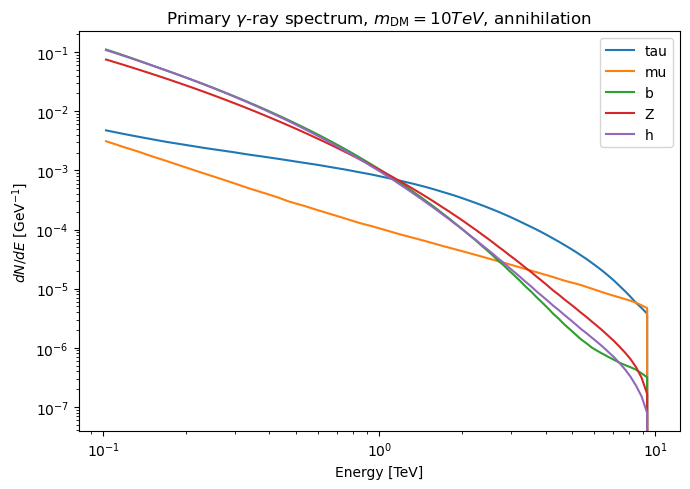

In [31]:
mDM = 10.0 * u.TeV
channels = ["tau", "mu", "b", "Z", "h"]

fig, ax = plt.subplots(figsize=(7, 5))

for channel in channels:
    fluxes = PrimaryFlux(mDM=mDM, channel=channel, source='cosmixs'
)
    fluxes.plot(
        energy_bounds=[mDM / 100, mDM],
        ax=ax,
        label=channel,
        yunits=u.Unit("1/GeV")
    )

ax.set_yscale("log")
ax.set_xlabel("Energy [TeV]")
ax.set_ylabel(r"$dN/dE$ [GeV$^{-1}$]")
ax.set_title(
    rf"Primary $\gamma$-ray spectrum, $m_{{\rm DM}} = {mDM:.0f}$, annihilation"
)
ax.legend()
plt.tight_layout()
plt.show()

## Expected Gamma-Ray Flux Map

Finally, we bring the astrophysical and particle physics components together.
The total expected gamma-ray flux from a DM source is the product of the 
astrophysical factor and the integrated energy spectrum:

**Annihilation:**
$$\Phi_{\rm ann}(>E_{\rm min}) = \frac{\langle\sigma v\rangle}{8\pi m_\chi^2} 
\cdot J \cdot \int_{E_{\rm min}}^{E_{\rm max}} \frac{dN}{dE} \, dE$$

**Decay:**
$$\Phi_{\rm dec}(>E_{\rm min}) = \frac{1}{4\pi \tau_\chi m_\chi} 
\cdot D \cdot \int_{E_{\rm min}}^{E_{\rm max}} \frac{dN}{dE} \, dE$$

The maps below show the absolute physical flux arriving at Earth 
(in cm⁻² s⁻¹), **before** any telescope instrumental effects are applied.
The spatial morphology is entirely determined by the J/D-factor map, while 
the overall normalization depends on the particle physics model.

> **Note:** For annihilation the relevant astrophysical factor is the 
> **J-factor** (proportional to ρ²), while for decay it is the **D-factor** 
> (proportional to ρ). Both were computed in the previous section.

The filename is not defined. Therefore, the model will not be serialised correctly. To set the filename, the "template_model.filename" attribute can be used.
The filename is not defined. Therefore, the model will not be serialised correctly. To set the filename, the "template_model.filename" attribute can be used.


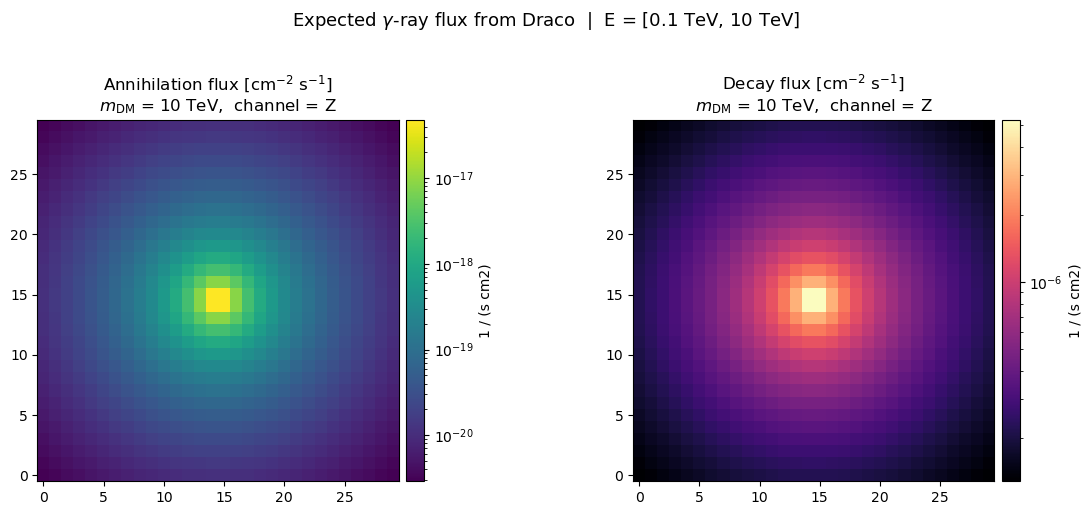

In [38]:
# Common parameters
channel  = "Z"
mass_DM  = 10 * u.TeV
E_min    = 0.1 * u.TeV
E_max    = mass_DM

# ------------------------------------------------------------------
# Annihilation flux  (uses J-factor, DarkMatterAnnihilationSpectralModel)
# ------------------------------------------------------------------
ann_model = DarkMatterAnnihilationSpectralModel(mass=mass_DM, channel=channel)
int_flux_ann = (
    jfact_draco * ann_model.integral(energy_min=E_min, energy_max=E_max)
).to("cm-2 s-1")

# ------------------------------------------------------------------
# Decay flux  (uses D-factor, DarkMatterDecaySpectralModel)
# For the D-factor we recompute JFactory with annihilation=False
# ------------------------------------------------------------------
jfactory_dec = JFactory(
    geom=geom_draco,
    profile=draco_profile,
    distance=distance_dwarf_draco,
    annihilation=False,
)
dfact_draco = jfactory_dec.compute_jfactor()

dec_model = DarkMatterDecaySpectralModel(mass=mass_DM, channel=channel)
int_flux_dec = (
    dfact_draco * dec_model.integral(energy_min=E_min, energy_max=E_max)
).to("cm-2 s-1")

# ------------------------------------------------------------------
# Plot side by side
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Annihilation ---
flux_map_ann = WcsNDMap(
    geom=geom_draco, data=int_flux_ann.value, unit="cm-2 s-1"
)
flux_map_ann.plot(
    ax=axes[0],
    cmap="viridis",
    norm=LogNorm(),
    add_cbar=True,
)
axes[0].set_title(
    f"Annihilation flux [cm$^{{-2}}$ s$^{{-1}}$]\n"
    f"$m_{{\\rm DM}}$ = {mass_DM:.0f},  channel = {channel}"
)

# --- Decay ---
flux_map_dec = WcsNDMap(
    geom=geom_draco, data=int_flux_dec.value, unit="cm-2 s-1"
)
flux_map_dec.plot(
    ax=axes[1],
    cmap="magma",
    norm=LogNorm(),
    add_cbar=True,
)
axes[1].set_title(
    f"Decay flux [cm$^{{-2}}$ s$^{{-1}}$]\n"
    f"$m_{{\\rm DM}}$ = {mass_DM:.0f},  channel = {channel}"
)

plt.suptitle(
    f"Expected $\\gamma$-ray flux from Draco  |  "
    f"E = [{E_min:.1f}, {E_max:.0f}]",
    fontsize=13,
    y=1.02,
)
plt.tight_layout()
plt.show()